# Bitcoin Price Forecasting — Corrected & Comparable Evaluation

This is a methodologically corrected version of the original notebook. The original compared XGBoost, Prophet, KMeans and LSTM, **but each model was evaluated differently** (XGBoost on ~870 test days, the others on only the last 7 days), several had **data leakage**, and KMeans/LSTM were scored against the **wrong dates**. Those flaws made the final comparison invalid.

### What was fixed
1. **One common, chronological test window** for every model (no shuffling of time).
2. **A naive baseline** (`tomorrow = today`) — the model every forecaster must beat.
3. **No data leakage**: scalers and Prophet are fit on the *training* portion only; XGBoost tuning uses `TimeSeriesSplit` instead of shuffled K-Fold.
4. **Matching dates**: predictions are compared to the actual values on the *same* dates.
5. **Time-series-appropriate metrics**: MAE, RMSE, MAPE and **directional accuracy** in addition to R².

All models below produce **1-day-ahead** forecasts of the closing price on the same test set, except Prophet which is shown as a genuine out-of-sample multi-step forecast over that window (its natural usage — caveat noted).

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.preprocessing import MinMaxScaler
import xgboost as xgb
from prophet import Prophet
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)

In [ ]:
# Download the data
ticker = "BTC-USD"
start_date = "2018-01-01"
end_date = "2025-05-31"
df = yf.download(ticker, start=start_date, end=end_date)

# yfinance can return a MultiIndex column (ticker level). Flatten it so df['Close'] works.
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)
df = df[['Close']].copy()
df.head()

/tmp/ipykernel_21977/3878767294.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


Price,Close
Date,
2018-01-01,13657.200195
2018-01-02,14982.099609
2018-01-03,15201.000000
2018-01-04,15599.200195
2018-01-05,17429.500000


## 1. Feature engineering

Every feature is computed only from information available **strictly before** the day being predicted: yesterday's-and-earlier lags and rolling statistics. This is what makes the XGBoost test predictions genuine 1-day-ahead forecasts.

In [ ]:
feat = df.copy()

# Lag features (past closes only)
feat['Lag1'] = feat['Close'].shift(1)
feat['Lag7'] = feat['Close'].shift(7)
feat['Lag30'] = feat['Close'].shift(30)

# Rolling stats are shifted by 1 so they NEVER include today's close (avoids leakage)
feat['Rolling_Mean_7']  = feat['Close'].rolling(7).mean().shift(1)
feat['Rolling_Mean_30'] = feat['Close'].rolling(30).mean().shift(1)
feat['Rolling_Std_7']   = feat['Close'].rolling(7).std().shift(1)

# Calendar features
feat['Year'] = feat.index.year
feat['Month'] = feat.index.month
feat['Day'] = feat.index.day
feat['Dayofweek'] = feat.index.dayofweek
feat['Is_weekend'] = (feat.index.dayofweek >= 5).astype(int)

feat = feat.dropna()

FEATURES = ['Year','Month','Day','Dayofweek','Is_weekend',
            'Lag1','Lag7','Lag30','Rolling_Mean_7','Rolling_Mean_30','Rolling_Std_7']

## 2. One common, chronological test window

We split by date (no shuffling). The **same** `test_data` index is used to score every model so the comparison is fair.

In [ ]:
split_date = '2024-06-01'   # last ~12 months held out for testing
train_data = feat.loc[:split_date].iloc[:-1]
test_data  = feat.loc[split_date:]

X_train, y_train = train_data[FEATURES], train_data['Close']
X_test,  y_test  = test_data[FEATURES],  test_data['Close']

print(f"Train: {train_data.index.min().date()} → {train_data.index.max().date()}  ({len(train_data)} rows)")
print(f"Test : {test_data.index.min().date()} → {test_data.index.max().date()}  ({len(test_data)} rows)")

Train: 2018-01-31 → 2024-05-31  (2313 rows)
Test : 2024-06-01 → 2025-05-30  (364 rows)


In [ ]:
# Unified evaluation: time-series-appropriate metrics
def evaluate(actual, predicted, name):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    mae  = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    r2   = r2_score(actual, predicted)
    # Directional accuracy: did we predict the right up/down move vs the previous actual?
    if len(actual) > 1:
        actual_dir = np.sign(np.diff(actual))
        pred_dir   = np.sign(predicted[1:] - actual[:-1])
        dir_acc = np.mean(actual_dir == pred_dir) * 100
    else:
        dir_acc = np.nan
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'MAPE_%': mape,
            'R2': r2, 'DirAcc_%': dir_acc}

results = []

## 3. Naive baseline (`tomorrow = today`)

For a random-walk-like asset such as Bitcoin this is a very strong baseline. **If a model cannot beat it, the model adds no value.**

In [ ]:
naive_pred = test_data['Lag1'].values   # Lag1 is yesterday's close == naive forecast
results.append(evaluate(y_test, naive_pred, 'Naive (t-1)'))
results[-1]

{'Model': 'Naive (t-1)',
 'MAE': 1483.278073489011,
 'RMSE': np.float64(2087.772469146989),
 'MAPE_%': np.float64(1.858494313613164),
 'R2': 0.9846131747760274,
 'DirAcc_%': np.float64(0.0)}

## 4. XGBoost — tuned with `TimeSeriesSplit` (no temporal leakage)

In [ ]:
param_dist = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [4, 6, 8],
    'n_estimators': [50, 100, 150],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
}

tscv = TimeSeriesSplit(n_splits=5)   # respects time order, unlike shuffled KFold
search = RandomizedSearchCV(
    xgb.XGBRegressor(objective='reg:squarederror', random_state=42),
    param_distributions=param_dist, n_iter=10, cv=tscv,
    scoring='neg_mean_absolute_error', random_state=42, n_jobs=-1,
)
search.fit(X_train, y_train)
best_xgb = search.best_estimator_
print('Best params:', search.best_params_)

xgb_pred = best_xgb.predict(X_test)
results.append(evaluate(y_test, xgb_pred, 'XGBoost'))
results[-1]

Best params: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 1.0}


{'Model': 'XGBoost',
 'MAE': 15881.214092548076,
 'RMSE': np.float64(21227.97626266717),
 'MAPE_%': np.float64(16.891562894921677),
 'R2': -0.5907424646258845,
 'DirAcc_%': np.float64(49.03581267217631)}

> **Note on tree models & trends:** XGBoost cannot extrapolate beyond the price range seen in training. Because it leans heavily on `Lag1`, its behaviour is close to the naive baseline — compare the two metrics rows to see whether the extra complexity is justified.

## 5. Prophet — fit on training data only

Prophet is fit only on the training period and then forecasts the entire test window out-of-sample. This is a genuine multi-step forecast (Prophet's natural mode), so it is at an inherent disadvantage versus the 1-day-ahead models — noted for transparency.

In [ ]:
p_train = train_data.reset_index()[['Date', 'Close']]
p_train.columns = ['ds', 'y']

m = Prophet(daily_seasonality=False, weekly_seasonality=True, yearly_seasonality=True)
m.fit(p_train)

future = pd.DataFrame({'ds': test_data.index})
fc = m.predict(future)
prophet_pred = fc['yhat'].values
results.append(evaluate(y_test, prophet_pred, 'Prophet'))
results[-1]

{'Model': 'Prophet',
 'MAE': 9811.555835754569,
 'RMSE': np.float64(11903.468764082008),
 'MAPE_%': np.float64(11.642645861687722),
 'R2': 0.4998160391589219,
 'DirAcc_%': np.float64(52.34159779614325)}

## 6. LSTM — scaler fit on train only, true 1-day-ahead walk-forward

The `MinMaxScaler` is fit on the **training** series only. For each test day we feed the 60 *actual* prior days and predict the next close, so every test prediction is a real 1-step-ahead forecast with no leakage.

In [ ]:
SEQ = 60
close = df['Close']

scaler = MinMaxScaler()
train_close = close.loc[:split_date].iloc[:-1].values.reshape(-1, 1)
scaler.fit(train_close)                       # fit on TRAIN only
scaled_all = scaler.transform(close.values.reshape(-1, 1)).flatten()

# Build training sequences from the training portion only
train_len = len(train_close)
Xtr, ytr = [], []
for i in range(SEQ, train_len):
    Xtr.append(scaled_all[i-SEQ:i]); ytr.append(scaled_all[i])
Xtr = np.array(Xtr).reshape(-1, SEQ, 1); ytr = np.array(ytr)

model = Sequential([
    Input((SEQ, 1)),
    LSTM(100, return_sequences=True), Dropout(0.2),
    LSTM(100), Dropout(0.2),
    Dense(1),
])
model.compile(optimizer='adam', loss='mse')
es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
model.fit(Xtr, ytr, epochs=100, batch_size=32, validation_split=0.1, callbacks=[es], verbose=1)

Epoch 1/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 0.0093 - val_loss: 0.0028
Epoch 2/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0016 - val_loss: 0.0044
Epoch 3/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0015 - val_loss: 0.0019
Epoch 4/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0014 - val_loss: 0.0024
Epoch 5/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0014 - val_loss: 0.0036
Epoch 6/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0013 - val_loss: 0.0029
Epoch 7/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0012 - val_loss: 0.0013
Epoch 8/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0014 - val_loss: 0.0027
Epoch 9/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0011 - val_loss: 0.0011
Epoch 10/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0011 - val_loss: 0.0025
Epoch 11/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0011 - val_loss: 0.0010
Epoch 12/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step

In [ ]:
# 1-day-ahead predictions across the test window using true prior history
all_close_vals = close.values
test_positions = [close.index.get_loc(d) for d in test_data.index]

seqs = np.array([scaled_all[p-SEQ:p] for p in test_positions]).reshape(-1, SEQ, 1)
lstm_scaled = model.predict(seqs).flatten()
lstm_pred = scaler.inverse_transform(lstm_scaled.reshape(-1, 1)).flatten()
results.append(evaluate(y_test, lstm_pred, 'LSTM'))
results[-1]

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


{'Model': 'LSTM',
 'MAE': 2795.658761160714,
 'RMSE': np.float64(3572.635968236488),
 'MAPE_%': np.float64(3.4220907157180314),
 'R2': 0.9549432128363899,
 'DirAcc_%': np.float64(48.209366391184574)}

## 7. KMeans — kept for completeness, but it is **not** a forecasting method

Clustering price *levels* and drawing a trend line through one cluster is effectively a linear extrapolation, not a recognised forecasting technique. It is included here only to mirror the original notebook, and is expected to perform poorly. Treat it as an illustration of *why* the approach is unsuitable, not as a serious model.

In [ ]:
from sklearn.cluster import KMeans

# Fit clusters on TRAIN closes only
km_scaler = MinMaxScaler()
train_scaled_for_km = km_scaler.fit_transform(y_train.values.reshape(-1, 1)) # Use y_train for consistency
km = KMeans(n_clusters=5, random_state=42, n_init=10).fit(train_scaled_for_km)

# Project a linear trend from the most recent training cluster across the test horizon
train_labels = km.labels_
recent_cluster = train_labels[-1]
recent_prices = y_train.values[train_labels == recent_cluster][-30:]
coeffs = np.polyfit(np.arange(len(recent_prices)), recent_prices, 1)
km_pred = np.polyval(coeffs, np.arange(len(recent_prices), len(recent_prices) + len(test_data)))
results.append(evaluate(y_test, km_pred, 'KMeans (illustrative)'))
results[-1]

{'Model': 'KMeans (illustrative)',
 'MAE': 46091.270315523696,
 'RMSE': np.float64(51037.57076433244),
 'MAPE_%': np.float64(57.1056628454185),
 'R2': -8.195231724995208,
 'DirAcc_%': np.float64(50.688705234159784)}

## 8. Fair comparison on the identical test window

In [ ]:
summary = pd.DataFrame(results).set_index('Model').round(3)
summary = summary.sort_values('MAE')
print(summary)
summary

                             MAE       RMSE  MAPE_%     R2  DirAcc_%
Model                                                               
Naive (t-1)             1483.278   2087.772   1.858  0.985     0.000
LSTM                    2795.659   3572.636   3.422  0.955    48.209
Prophet                 9811.556  11903.469  11.643  0.500    52.342
XGBoost                15881.214  21227.976  16.892 -0.591    49.036
KMeans (illustrative)  46091.270  51037.571  57.106 -8.195    50.689


,MAE,RMSE,MAPE_%,R2,DirAcc_%
Model,,,,,
Naive (t-1),1483.278,2087.772,1.858,0.985,0.000
LSTM,2795.659,3572.636,3.422,0.955,48.209
Prophet,9811.556,11903.469,11.643,0.500,52.342
XGBoost,15881.214,21227.976,16.892,-0.591,49.036
KMeans (illustrative),46091.270,51037.571,57.106,-8.195,50.689


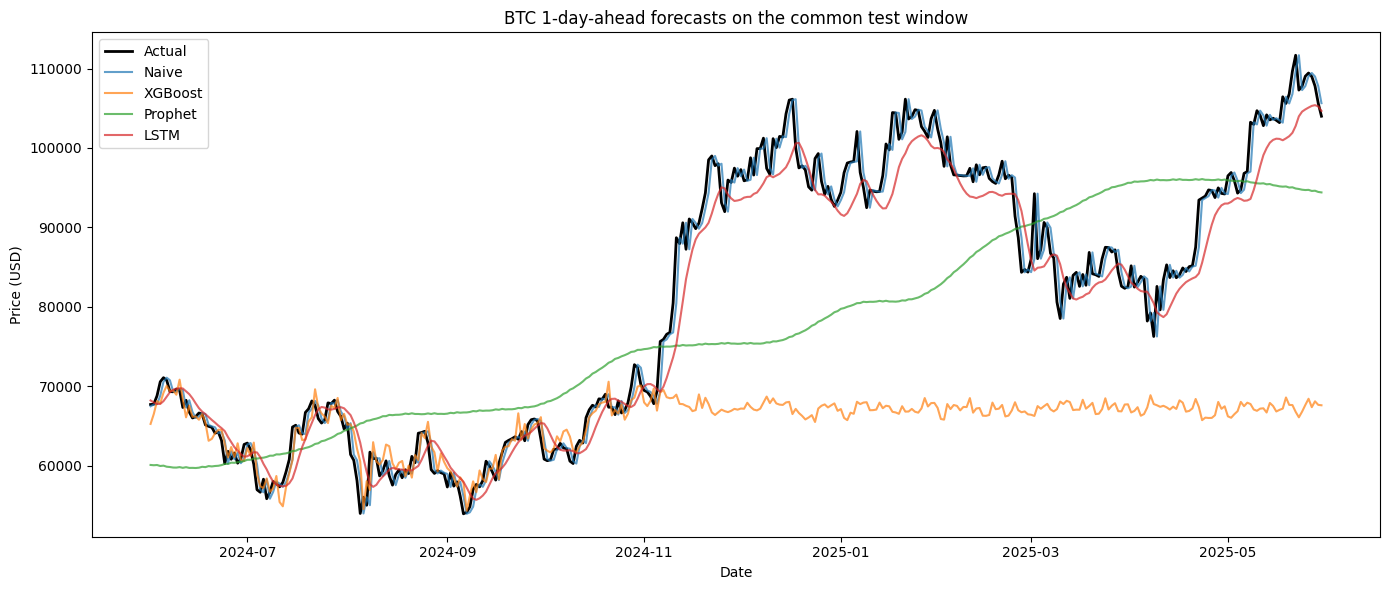

In [ ]:
# Predictions vs actual on the common test window
plt.figure(figsize=(14, 6))
plt.plot(test_data.index, y_test, label='Actual', color='black', linewidth=2)
plt.plot(test_data.index, naive_pred,   label='Naive',   alpha=0.7)
plt.plot(test_data.index, xgb_pred,     label='XGBoost', alpha=0.7)
plt.plot(test_data.index, prophet_pred, label='Prophet', alpha=0.7)
plt.plot(test_data.index, lstm_pred,    label='LSTM',    alpha=0.7)
plt.title('BTC 1-day-ahead forecasts on the common test window')
plt.xlabel('Date'); plt.ylabel('Price (USD)'); plt.legend(); plt.tight_layout()
plt.show()

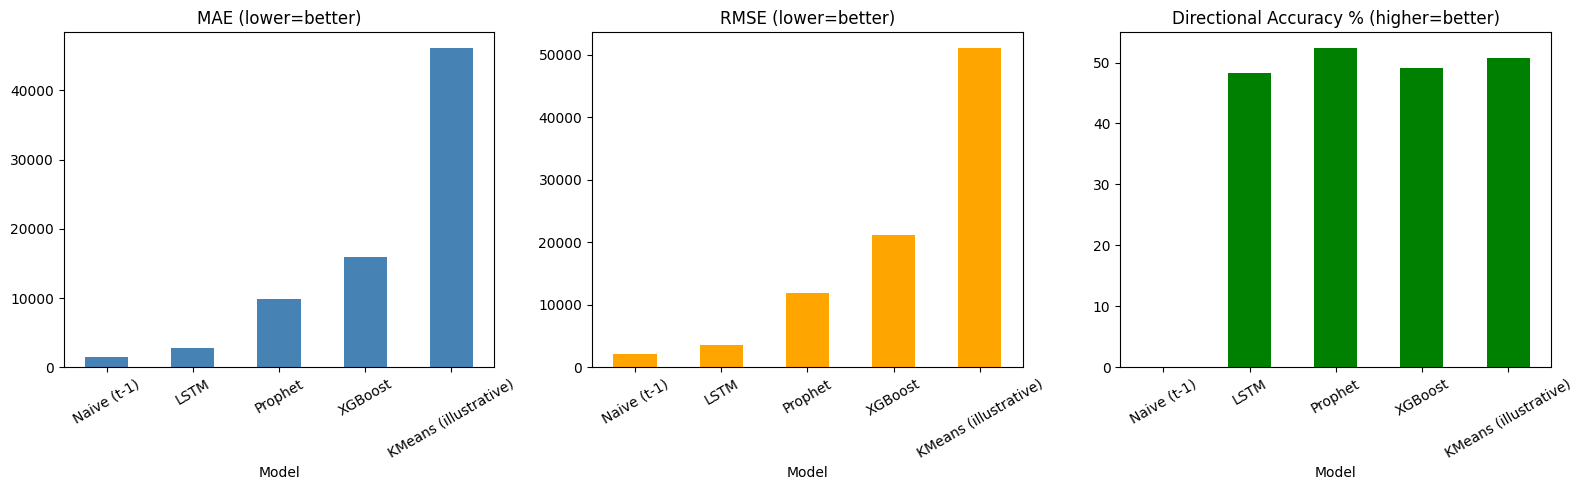

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(16, 5))
summary['MAE'].plot.bar(ax=axs[0], color='steelblue', title='MAE (lower=better)')
summary['RMSE'].plot.bar(ax=axs[1], color='orange',  title='RMSE (lower=better)')
summary['DirAcc_%'].plot.bar(ax=axs[2], color='green', title='Directional Accuracy % (higher=better)')
for a in axs: a.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

## 9. How to read these results

- Compare every model against the **Naive (t-1)** row. For daily Bitcoin, beating the naive baseline on MAE/RMSE is genuinely hard; matching it is the realistic outcome for the 1-step models.
- **Directional accuracy ~50%** means the model is no better than a coin flip at calling up/down — important context that R² hides.
- **Prophet** is multi-step here, so larger errors are expected and are not directly comparable to the 1-step models.
- **KMeans** is included only to demonstrate that clustering is not a forecasting tool.

The honest conclusion this notebook supports: *on a fair, leakage-free backtest, the machine-learning models struggle to beat a naive random-walk baseline* — a well-known and respectable finding for crypto price prediction.